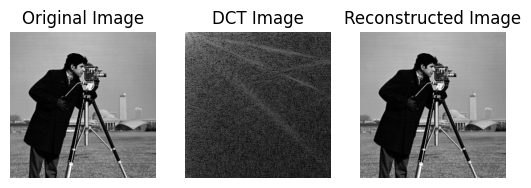

In [ ]:
-import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/cameraman.bmp',0)

img = np.float32(img)

dct = cv2.dct(img)

idct = cv2.idct(dct)

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.log(1+abs(dct)), cmap='gray')   # log for better visibility
plt.title("DCT Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(idct, cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

plt.show()

In [ ]:
# Define 8×8 block (given values)
I = [
[154,123,123,123,123,123,123,136],
[192,180,136,154,154,154,136,110],
[254,198,154,154,180,154,123,123],
[239,180,136,180,180,166,123,123],
[180,154,136,167,166,149,136,136],
[128,136,123,136,154,180,198,154],
[123,105,110,149,136,136,180,166],
[110,136,123,123,123,136,154,136]
]

# Subtract 128 (center pixel values around zero)
M = I - 128

# Create empty DCT transform matrix
T = np.zeros((8,8))

# Fill DCT matrix using formula
for i in range(8):
    for j in range(8):
        if i == 0:
            T[i,j] = np.sqrt(1/8)   # first row formula
        else:
            T[i,j] = np.sqrt(2/8) * np.cos(((2*j+1)*i*np.pi)/16)

# Apply DCT (frequency transform)
D = T @ M @ T.T

# Define quantization matrix (compression matrix)
Q =[
[16,11,10,16,24,40,51,61],
[12,12,14,19,26,58,60,55],
[14,13,16,24,40,57,69,56],
[14,17,22,29,51,87,80,62],
[18,22,37,56,68,109,103,77],
[24,35,55,64,81,104,113,92],
[49,64,78,87,103,121,120,101],
[72,92,95,98,112,100,103,99]
]

# Quantization (compression step)
C = np.round(D / Q)

# Dequantization (reverse compression)
R = C * Q

# Apply inverse DCT (reconstruct block)
N = np.round(T.T @ R @ T + 128)

print("Original Matrix:\n", I)
print("\nAfter Subtract 128 (M):\n", M)
print("\nDCT Matrix (D):\n", D)
print("\nQuantized Matrix (C):\n", C)
print("\nReconstructed Matrix (N):\n", N)

Original Matrix:
 [[154 123 123 123 123 123 123 136]
 [192 180 136 154 154 154 136 110]
 [254 198 154 154 180 154 123 123]
 [239 180 136 180 180 166 123 123]
 [180 154 136 167 166 149 136 136]
 [128 136 123 136 154 180 198 154]
 [123 105 110 149 136 136 180 166]
 [110 136 123 123 123 136 154 136]]

After Subtract 128 (M):
 [[ 26  -5  -5  -5  -5  -5  -5   8]
 [ 64  52   8  26  26  26   8 -18]
 [126  70  26  26  52  26  -5  -5]
 [111  52   8  52  52  38  -5  -5]
 [ 52  26   8  39  38  21   8   8]
 [  0   8  -5   8  26  52  70  26]
 [ -5 -23 -18  21   8   8  52  38]
 [-18   8  -5  -5  -5   8  26   8]]

DCT Matrix (D):
 [[ 1.62250000e+02  4.05989816e+01  2.00026918e+01  7.23294009e+01
   3.02500000e+01  1.24848354e+01 -1.96505043e+01 -1.14971452e+01]
 [ 3.04792937e+01  1.08415970e+02  1.04730992e+01  3.22925175e+01
   2.76990885e+01 -1.55048925e+01  1.84075948e+01 -1.99566961e+00]
 [-9.41445075e+01 -6.00511329e+01  1.22980970e+01 -4.34188963e+01
  -3.12878702e+01  6.06690905e+00 -3.3305826